# Basic Idea

The model heirarchy (I think) is something like:

Everyone has a common dispersion (r)

Every condition has a common Beta distribution (alpha, beta)

Every individual has a probability sampled from their relevant Beta distribution.

Every cell has a size factor we can pre-compute (s)

So we get something like 

$$
p \sim B(\alpha, \beta)
$$
$$
X \sim NB(r \cdot s, p)
$$

We can then ask questions about whether two groups beta distributions show very different distributions.
In this case, we'll do something people are talking about recently, PLIN2 expression in immune cells (in this case, we have macrophages in the CPE).

In [1]:
import scanpy as sc

adata = sc.read_h5ad("/oak/stanford/projects/kibr/Reorganizing/Projects/James/negative-binomial-pyro/../choroid-plexus-cell-atlas/data/new_annotations.h5ad")
adata = adata[adata.obs["Cell.Subtype"].eq("Macrophage")].copy()

In [2]:
df = adata.obs \
    .assign(expression = adata[:, "PLIN2"].X.todense().reshape(-1).tolist()[0]) \
    .assign(size_factor = adata.X.sum(axis=1).reshape(-1).tolist()[0]) \
    .eval("size_factor = size_factor / size_factor.mean()") \
    [["orig.ident", "cogdx", "expression", "size_factor"]]

df["cogdx"].replace({1: 0, 2: 1, 4: 2}, inplace=True)

/tmp/ipykernel_25124/976806447.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["cogdx"].replace({1: 0, 2: 1, 4: 2}, inplace=True)


In [8]:
import pyro
import pyro.distributions as dist
import torch
from pyro.nn import PyroModule
from pyro.infer import SVI, Trace_ELBO, TraceMeanField_ELBO
from pyro.optim import ClippedAdam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

y = torch.tensor(df["expression"]).float().to(device)
size_factors = torch.tensor(df["size_factor"]).float().to(device)
individual = torch.tensor(df["orig.ident"].cat.codes).long().to(device)
group = torch.tensor(df["cogdx"]).long().to(device)

/tmp/ipykernel_25124/3607464877.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = torch.tensor(df["expression"]).float().to(device)
/tmp/ipykernel_25124/3607464877.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  size_factors = torch.tensor(df["size_factor"]).float().to(device)
/tmp/ipykernel_25124/3607464877.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  individual = torch.tensor(df["orig.ident"].cat.codes).long().

In [9]:
import importlib
importlib.reload(src)
import src.cuda

In [10]:
import sys
sys.path.append(".")
import src.model

pyro.clear_param_store()
optimizer = ClippedAdam({'lr': 1e-3, 'clip_norm': 10.0})
elbo = TraceMeanField_ELBO(num_particles=10)
svi = SVI(src.cuda.model, src.cuda.guide, optimizer, loss=elbo)

losses = []
for step in range(5_000):
    loss = svi.step(
        y, 
        size_factors, 
        individual, 
        group
    )

    losses.append(loss)

    if step % 1 == 0:
        print(f"Step {step} - ELBO: {loss:.2f}")

with open(f"output/{gene.replace('/', '--')}.txt", "w") as f:
    f.write("Model parameters:\n")
    for name, param in pyro.get_param_store().items():
        f.write(f"{name}: {param.detach().clone().tolist()}\n")

Just to show our sampling has converged

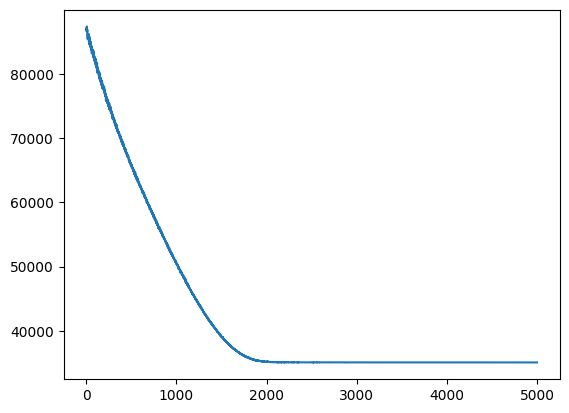

In [62]:
import matplotlib.pyplot as plt
plt.plot(losses)

We can return our estimates.

In [74]:

# Return final parameter estimates
for k, v in {name: pyro.get_param_store()[name].detach().clone() for name in pyro.get_param_store()}.items():
    if "logit_p" in k:
        break
    print(f"{k}: {v.tolist()}")

log_alpha_loc: [1.9863580465316772, 2.006147861480713, 2.008826732635498]
log_alpha_scale: [0.007636900059878826, 0.006771143991500139, 0.0075503503903746605]
log_beta_loc: [2.005809783935547, 2.0011298656463623, 2.0041558742523193]
log_beta_scale: [0.007565782405436039, 0.006867830641567707, 0.0075522372499108315]
log_r_loc: 0.40447646379470825
log_r_scale: 0.008427680470049381


To determine if there is a difference, lets see if the parameters we infer for the alpha and beta of each of these groups distribute very differently from one another.

In [64]:
import torch

# Assume you have learned log_alpha_loc, log_alpha_scale, etc. (G=3)
G = len(pyro.param("log_alpha_loc"))
S = 10000  # num posterior samples

alpha_samples = torch.exp(torch.randn(S, G) * pyro.param("log_alpha_scale") + pyro.param("log_alpha_loc"))
beta_samples  = torch.exp(torch.randn(S, G) * pyro.param("log_beta_scale")  + pyro.param("log_beta_loc"))

# Optional: sample full Beta distributions from each group
from torch.distributions import Beta
beta_dists = [Beta(alpha_samples[:,g], beta_samples[:,g]) for g in range(G)]

# Compare samples across groups (e.g. group 0 vs 1)
diff = (beta_dists[0].mean - beta_dists[2].mean)
